In [1]:
import pandas as pd

url = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

credit_reporting_variants = [
    'Credit reporting',
    'Credit reporting or other personal consumer reports',
    'Credit reporting, credit repair services, or other personal consumer reports'
]

payday_variants = [
    'Payday loan',
    'Payday loan, title loan, or personal loan',
    'Payday loan, title loan, personal loan, or advance loan'
]

bank_variants = [
    'Bank account or service',
    'Checking or savings account'
]

credit_card_variants = [
    'Credit card',
    'Credit card or prepaid card',
    'Prepaid card'
]

money_transfer_variants = [
    'Money transfers',
    'Virtual currency',
    'Money transfer, virtual currency, or money service'
]

company_response_variants = [
    'Closed',
    'Closed with explanation'
]

referral_variants = [
    'Referral',
    'Web Referral'
]

manual_variants = [
    'Email',
    'Fax',
    'Postal mail'
]

needed_cols = [
    'Date received',
    'Date sent to company',
    'Product',
    'Submitted via',
    'Company response to consumer',
    'Timely response?'
]

start_date = pd.to_datetime('2017-01-20')

print("Processing in chunks to save RAM...")

chunks = []
for chunk in pd.read_csv(url,
                         compression='zip',
                         usecols=needed_cols,
                         chunksize=100000,
                         low_memory=False):
    chunk['Product'] = chunk['Product'].replace(credit_reporting_variants, 'Credit Reporting')
    chunk['Product'] = chunk['Product'].replace(payday_variants, 'Payday Loan')
    chunk['Product'] = chunk['Product'].replace(bank_variants, 'Bank Account or Service')
    chunk['Product'] = chunk['Product'].replace(credit_card_variants, 'Credit Card or Prepaid Card')
    chunk['Product'] = chunk['Product'].replace(money_transfer_variants, 'Money Transfer, Virtual Currency, or Money Service')
    chunk['Company response to consumer'] = chunk['Company response to consumer'].replace(company_response_variants, 'Closed with Explanation')
    chunk['Submitted via'] = chunk['Submitted via'].replace(manual_variants, 'Email, Fax, or Postal Mail')
    chunk['Submitted via'] = chunk['Submitted via'].replace(referral_variants, 'Referral')
    chunk['Date received'] = pd.to_datetime(chunk['Date received'])
    filtered_chunk = chunk[chunk['Date received'] >= start_date]

    chunks.append(filtered_chunk)

df = pd.concat(chunks, ignore_index=True)

print(f"Success! Dataframe loaded with {len(df):,} rows.")
print(f"Date range: {df['Date received'].min().date()} to {df['Date received'].max().date()}")

df.head()

Processing in chunks to save RAM...
Success! Dataframe loaded with 13,443,074 rows.
Date range: 2017-01-20 to 2026-03-25


,Date received,Product,Submitted via,Date sent to company,Company response to consumer,Timely response?
0,2020-07-06,Credit Reporting,Web,2020-07-06,Closed with Explanation,Yes
1,2019-12-26,Credit Card or Prepaid Card,Web,2019-12-26,Closed with Explanation,Yes
2,2020-05-08,Credit Reporting,Web,2020-05-08,Closed with Explanation,Yes
3,2024-01-05,Credit Reporting,Web,2024-01-05,Closed with non-monetary relief,Yes
4,2024-01-21,Credit Reporting,Web,2024-01-21,Closed with Explanation,Yes


In [2]:
df.shape

(13443074, 6)

In [3]:
new_names = {'Date received': 'date_received', 'Product': 'product', 'Submitted via':'submitted_via', 'Date sent to company':'date_sent_to_company', 'Company response to consumer':'company_response_to_consumer', 'Timely response?':'timely_response'}
df = df.rename(columns=new_names)
categorical_cols = ['product', 'submitted_via', 'company_response_to_consumer', 'timely_response']
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [4]:
fraction_similar = (((df['date_received'] == df['date_sent_to_company']).sum())/df.shape[0])
print(f"Similarity between the date the CFPB received the complaint and the date the CFPB sent the complaint to the company: {fraction_similar:.2%}")

Similarity between the date the CFPB received the complaint and the date the CFPB sent the complaint to the company: 95.15%


In [5]:
# https://cfpb.github.io/api/ccdb/fields.html
df.drop('date_received', axis = 1, inplace = True)
df['date_sent_to_company'] = pd.to_datetime(df['date_sent_to_company'])
df.head()

,product,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response
0,Credit Reporting,Web,2020-07-06,Closed with Explanation,Yes
1,Credit Card or Prepaid Card,Web,2019-12-26,Closed with Explanation,Yes
2,Credit Reporting,Web,2020-05-08,Closed with Explanation,Yes
3,Credit Reporting,Web,2024-01-05,Closed with non-monetary relief,Yes
4,Credit Reporting,Web,2024-01-21,Closed with Explanation,Yes


In [6]:
df = df[df['company_response_to_consumer'] != 'In progress']
bins = [
    pd.Timestamp('2017-01-20'),
    pd.Timestamp('2021-01-20'),
    pd.Timestamp('2025-01-20'),
    pd.Timestamp('2029-01-20')
]

labels = ['Trump_One', 'Biden', 'Trump_Two']

df['president_date_sent_to_company'] = pd.cut(df['date_sent_to_company'], bins=bins, labels=labels, right=False, ordered=False)
df.head()

,product,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,president_date_sent_to_company
0,Credit Reporting,Web,2020-07-06,Closed with Explanation,Yes,Trump_One
1,Credit Card or Prepaid Card,Web,2019-12-26,Closed with Explanation,Yes,Trump_One
2,Credit Reporting,Web,2020-05-08,Closed with Explanation,Yes,Trump_One
3,Credit Reporting,Web,2024-01-05,Closed with non-monetary relief,Yes,Biden
4,Credit Reporting,Web,2024-01-21,Closed with Explanation,Yes,Biden


In [7]:
df['product'].value_counts()

,count
product,
Credit Reporting,10626406
Debt collection,899437
Credit Card or Prepaid Card,432564
Bank Account or Service,353625
Mortgage,224825
"Money Transfer, Virtual Currency, or Money Service",171586
Student loan,97781
Vehicle loan or lease,90018
Payday Loan,58831


In [8]:
df['submitted_via'].value_counts()

,count
submitted_via,
Web,12581838
Phone,162470
Referral,144569
"Email, Fax, or Postal Mail",77217


In [9]:
df['company_response_to_consumer'].value_counts()

,count
company_response_to_consumer,
Closed with Explanation,7889009
Closed with non-monetary relief,4901505
Closed with monetary relief,153570
Untimely response,21989
In progress,0


In [31]:
# df = df[df['product'] != 'Virtual currency']
# df = df[df['product'] != 'Other financial service']
# df = df[df['product'] != 'Money transfers']
# df = df[df['submitted_via'] != 'Email']
# df = df[df['submitted_via'] != 'Web Referral']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12966094 entries, 0 to 13443073
Data columns (total 6 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   product                         category      
 1   submitted_via                   category      
 2   date_sent_to_company            datetime64[ns]
 3   company_response_to_consumer    category      
 4   timely_response                 category      
 5   president_date_sent_to_company  category      
dtypes: category(5), datetime64[ns](1)
memory usage: 259.7 MB


In [11]:
df.drop('date_sent_to_company', axis = 1, inplace = True)

In [12]:
df.describe(include='all')

,product,submitted_via,company_response_to_consumer,timely_response,president_date_sent_to_company
count,12966094,12966094,12966073,12966094,12966094
unique,12,4,4,2,3
top,Credit Reporting,Web,Closed with Explanation,Yes,Trump_Two
freq,10626406,12581838,7889009,12892516,6162139


In [13]:
missing_values = df.isnull().sum()

missing_values_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})
missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
company_response_to_consumer,21,0.000162
product,0,0.000000
submitted_via,0,0.000000
timely_response,0,0.000000
president_date_sent_to_company,0,0.000000


In [14]:
df.dropna(inplace=True)
df.head()

,product,submitted_via,company_response_to_consumer,timely_response,president_date_sent_to_company
0,Credit Reporting,Web,Closed with Explanation,Yes,Trump_One
1,Credit Card or Prepaid Card,Web,Closed with Explanation,Yes,Trump_One
2,Credit Reporting,Web,Closed with Explanation,Yes,Trump_One
3,Credit Reporting,Web,Closed with non-monetary relief,Yes,Biden
4,Credit Reporting,Web,Closed with Explanation,Yes,Biden


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

ohe_cols = ['product', 'submitted_via', 'company_response_to_consumer',
       'timely_response']
encoder = OneHotEncoder(sparse_output=True, drop='first')
X_sparse = encoder.fit_transform(df[ohe_cols])

In [16]:
column_names = encoder.get_feature_names_out(ohe_cols)
column_names

array(['product_Consumer Loan', 'product_Credit Card or Prepaid Card',
       'product_Credit Reporting', 'product_Debt collection',
       'product_Debt or credit management',
       'product_Money Transfer, Virtual Currency, or Money Service',
       'product_Mortgage', 'product_Other financial service',
       'product_Payday Loan', 'product_Student loan',
       'product_Vehicle loan or lease', 'submitted_via_Phone',
       'submitted_via_Referral', 'submitted_via_Web',
       'company_response_to_consumer_Closed with monetary relief',
       'company_response_to_consumer_Closed with non-monetary relief',
       'company_response_to_consumer_Untimely response',
       'timely_response_Yes'], dtype=object)

In [17]:
y = df['president_date_sent_to_company']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_sparse,
    y,
    test_size=0.3,
    random_state=5,
    stratify=y
)
import gc
del X_sparse
del df
gc.collect()

0

In [18]:
# https://stackoverflow.com/questions/29294983/how-to-calculate-correlation-between-all-columns-and-remove-highly-correlated-on
# source: https://www.statology.org/cramers-v-in-python/
import pandas as pd
import numpy as np

sample_size = min(100000, X_train.shape[0])
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample_sparse = X_train[indices]

X_sample_df = pd.DataFrame(X_sample_sparse.toarray(), columns=column_names)

corr_matrix = X_sample_df.corr().abs()

corr_pairs = corr_matrix.unstack()
highly_correlated_pairs = corr_pairs[
    (corr_pairs >= 0.7) & (corr_pairs < 1.0)
].sort_values(ascending=False)

print("Highly correlated pairs found in sample:")
print(highly_correlated_pairs)

Highly correlated pairs found in sample:
Series([], dtype: float64)


In [19]:
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sample_size = min(100000, X_train.shape[0])
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample_df = pd.DataFrame(X_train[indices].toarray(), columns=column_names)
vif_data = add_constant(X_sample_df)

vif_series = pd.DataFrame()
vif_series["Feature"] = vif_data.columns
vif_series["VIF"] = [variance_inflation_factor(vif_data.values, i)
                     for i in range(vif_data.shape[1])]

print(vif_series[vif_series['Feature'] != 'const'].sort_values(by="VIF", ascending=False))

                                              Feature       VIF
3                            product_Credit Reporting  6.421871
14                                  submitted_via_Web  4.835514
4                             product_Debt collection  3.606499
12                                submitted_via_Phone  3.101192
13                             submitted_via_Referral  2.803259
2                 product_Credit Card or Prepaid Card  2.207612
7                                    product_Mortgage  1.613894
6   product_Money Transfer, Virtual Currency, or M...  1.497673
18                                timely_response_Yes  1.485399
17     company_response_to_consumer_Untimely response  1.469724
10                               product_Student loan  1.294463
11                      product_Vehicle loan or lease  1.252799
9                                 product_Payday Loan  1.167260
15  company_response_to_consumer_Closed with monet...  1.139217
16  company_response_to_consumer_Closed 

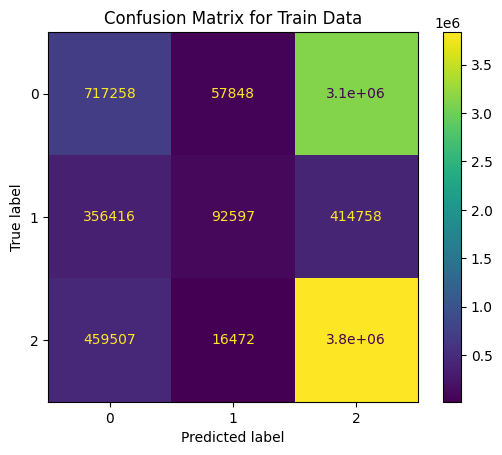

Accuracy on Training: 0.5120366327462738
Balanced Accuracy on Training: 0.3936049048518959


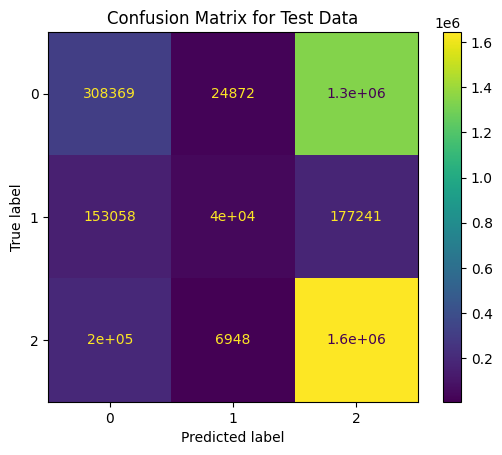

Test Set Accuracy: 0.5121601965334146
Test Set Balanced Accuracy: 0.3938574646565776


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt

lr = LogisticRegression(max_iter=10000, random_state=5).fit(X_train, y_train)
predictions_training = lr.predict(X_train)
cm = confusion_matrix(y_train, predictions_training)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Train Data')
plt.show()
print('Accuracy on Training:', accuracy_score(y_train, predictions_training))
print('Balanced Accuracy on Training:', balanced_accuracy_score(y_train, predictions_training))
predictions = lr.predict(X_test)
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Test Data')
plt.show()
print('Test Set Accuracy:', accuracy_score(y_test, predictions))
print('Test Set Balanced Accuracy:', balanced_accuracy_score(y_test, predictions))

In [21]:
coef_df = pd.DataFrame(
    lr.coef_,
    columns=column_names,
    index=lr.classes_
).T

# Positive values mean that feature increases the probability of that era
# Negative values mean it decreases the probability
print("Coefficients by Feature and Administration:")
display(coef_df)

for admin in lr.classes_:
    print(f"\n--- Top 5 Features predicting the {admin} Era ---")
    print(coef_df[admin].sort_values(ascending=False).head(5))

Coefficients by Feature and Administration:


,Biden,Trump_One,Trump_Two
product_Consumer Loan,-1.322193,2.171900,-0.849707
product_Credit Card or Prepaid Card,-0.125820,0.197862,-0.072042
product_Credit Reporting,-0.158099,-0.556493,0.714592
product_Debt collection,-0.407421,0.252101,0.155320
product_Debt or credit management,0.099040,-1.168732,1.069692
"product_Money Transfer, Virtual Currency, or Money Service",0.102422,-0.296000,0.193579
product_Mortgage,-0.167666,0.788282,-0.620616
product_Other financial service,-0.093831,0.139470,-0.045639
product_Payday Loan,-0.200138,0.256146,-0.056008
product_Student loan,-0.363315,0.641332,-0.278017



--- Top 5 Features predicting the Biden Era ---
company_response_to_consumer_Closed with non-monetary relief    0.563676
submitted_via_Phone                                             0.514115
submitted_via_Web                                               0.308555
submitted_via_Referral                                          0.126144
product_Money Transfer, Virtual Currency, or Money Service      0.102422
Name: Biden, dtype: float64

--- Top 5 Features predicting the Trump_One Era ---
product_Consumer Loan      2.171900
product_Mortgage           0.788282
product_Student loan       0.641332
product_Payday Loan        0.256146
product_Debt collection    0.252101
Name: Trump_One, dtype: float64

--- Top 5 Features predicting the Trump_Two Era ---
submitted_via_Web                                 1.513446
product_Debt or credit management                 1.069692
company_response_to_consumer_Untimely response    1.047934
product_Credit Reporting                          0.714592
subm

In [22]:
intercept_df = pd.DataFrame(lr.intercept_, index=lr.classes_, columns=['Intercept'])
print(intercept_df)

           Intercept
Biden       0.229265
Trump_One   1.564703
Trump_Two  -1.793968


In [23]:
import numpy as np
import pandas as pd

odds_ratios = np.exp(lr.coef_)

or_df = pd.DataFrame(
    odds_ratios,
    columns=column_names,
    index=lr.classes_
).T

# "Percent Change" version for easier reading
pct_df = (or_df - 1) * 100

print("--- Odds Ratios (Likelihood Multiplier) ---")
display(or_df.head(10))

for admin in lr.classes_:
    print(f"\nTop indicators for {admin}:")
    # Sort by the highest percentage increase
    top_indicators = pct_df[admin].sort_values(ascending=False).head(5)
    for feature, val in top_indicators.items():
        print(f" > {feature}: {val:.1f}% more likely")

--- Odds Ratios (Likelihood Multiplier) ---


,Biden,Trump_One,Trump_Two
product_Consumer Loan,0.266550,8.774937,0.427540
product_Credit Card or Prepaid Card,0.881774,1.218794,0.930492
product_Credit Reporting,0.853766,0.573216,2.043352
product_Debt collection,0.665364,1.286727,1.168032
product_Debt or credit management,1.104110,0.310761,2.914483
"product_Money Transfer, Virtual Currency, or Money Service",1.107851,0.743787,1.213585
product_Mortgage,0.845636,2.199614,0.537613
product_Other financial service,0.910437,1.149664,0.955387
product_Payday Loan,0.818618,1.291941,0.945531
product_Student loan,0.695367,1.899009,0.757284



Top indicators for Biden:
 > company_response_to_consumer_Closed with non-monetary relief: 75.7% more likely
 > submitted_via_Phone: 67.2% more likely
 > submitted_via_Web: 36.1% more likely
 > submitted_via_Referral: 13.4% more likely
 > product_Money Transfer, Virtual Currency, or Money Service: 10.8% more likely

Top indicators for Trump_One:
 > product_Consumer Loan: 777.5% more likely
 > product_Mortgage: 120.0% more likely
 > product_Student loan: 89.9% more likely
 > product_Payday Loan: 29.2% more likely
 > product_Debt collection: 28.7% more likely

Top indicators for Trump_Two:
 > submitted_via_Web: 354.2% more likely
 > product_Debt or credit management: 191.4% more likely
 > company_response_to_consumer_Untimely response: 185.2% more likely
 > product_Credit Reporting: 104.3% more likely
 > submitted_via_Referral: 65.8% more likely
